# 07 Sparse Multi Input example using the Abalone dataset

_[Estimated time of execution: 5 min]_

This notebook shows how to train a multi-input dataset using MOGPTK.

Abalone is a dataset containing the measurements of 4177 abalones (a type of marine snail) for their lengths, weights, sex and age. Specifically, the following features are given:

- Sex: M, F, and I (infant)
- Length in mm: longest shell measurement
- Diameter in mm: perpendicular to length
- Height in mm: with meat in shell
- Whole weight in grams: whole abalone
- Shucked weight in grams: weight of meat
- Viscera weight in grams: gut weight (after bleeding)
- Shell weight in grams: after being dried
- Rings: +1.5 gives the age in years

Here we will use the length and weight features as independent variables, and the number of rings (i.e. their age) as the dependent variable.

In [1]:
import numpy as np
import torch
import mogptk

torch.manual_seed(1);

Load in the dataset and select the relevant columns. Then standardize the number of rings so that it has zero mean and unit variance.

In [2]:
columns = ["Sex","Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight","Rings"]

data = mogptk.LoadCSV("data/abalone/abalone.data",
                      x_col=["Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight"],
                      y_col=["Rings"], names=columns)
data.transform(mogptk.TransformNormalize())

Set up the model by using Titsias' sparse Gaussian process inference with a `100` inducing (sparse) points. The initial points will be spread randomly over the input space.

We will use the squared exponential kernel with our 7 input dimensions. We initialize the parameters to values that are close to the minimum to help training.

In [3]:
# Choose kernel
kernel = mogptk.gpr.SquaredExponentialKernel(input_dims=7)

# Choose inference
inference = mogptk.Titsias(inducing_points=100, init_inducing_points='random')

# Set up model
model = mogptk.Model(data, kernel, inference=inference)

# Initialize parameters
model.gpr.kernel.lengthscale.assign(np.random.rand(7))

Training will be performed using the default Adam optimizer with a learning rate of `1.0` for a `100` iterations. We will additionally be measuring the error between the prediction and the target values using the mean absolute percentage error (MAPE), which is a relative error with respect to the target values. In our case, we are able to reach a 16% error relative to the target values.

In [4]:
model.train(iters=500, verbose=True, error='mape', lr=0.05)

Starting optimization using Adam
‣ Model: Titsias
  ‣ Kernel: SquaredExponentialKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 1
‣ Parameters: 709
‣ Training points: 4177
‣ Iterations: 500


C:\Users\Usuario UTP\Documents\Doctorado\mogptk\mogptk\model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.gpr.loss())


    0/500   0:00:01  loss=     4480.37  error=     17.0359
  136/500   0:00:10  loss=     1305.12  error=     15.0499
  329/500   0:00:20  loss=       -1426  error=     14.9274
  500/500   0:00:28  loss=    -1959.59  error=     14.8314
Optimization finished in 28.920 seconds


(array([ 4.48036747e+03,  4.20593512e+03,  4.04236041e+03,  3.94359892e+03,
         3.88341026e+03,  3.84422881e+03,  3.81525662e+03,  3.79160684e+03,
         3.76971106e+03,  3.74909049e+03,  3.72921694e+03,  3.70849388e+03,
         3.68687321e+03,  3.66547605e+03,  3.64528738e+03,  3.62536328e+03,
         3.60535729e+03,  3.58514217e+03,  3.56448680e+03,  3.54443003e+03,
         3.52451535e+03,  3.50445627e+03,  3.48447458e+03,  3.46455117e+03,
         3.44476220e+03,  3.42506365e+03,  3.40531129e+03,  3.38549604e+03,
         3.36575294e+03,  3.34606444e+03,  3.32636801e+03,  3.30664161e+03,
         3.28691070e+03,  3.26722602e+03,  3.24755707e+03,  3.22789848e+03,
         3.20827461e+03,  3.18867313e+03,  3.16910220e+03,  3.14953939e+03,
         3.12994918e+03,  3.11038042e+03,  3.09082604e+03,  3.07128203e+03,
         3.05174838e+03,  3.03222616e+03,  3.01270771e+03,  2.99320094e+03,
         2.97370703e+03,  2.95421835e+03,  2.93473755e+03,  2.91526495e+03,
         2.8

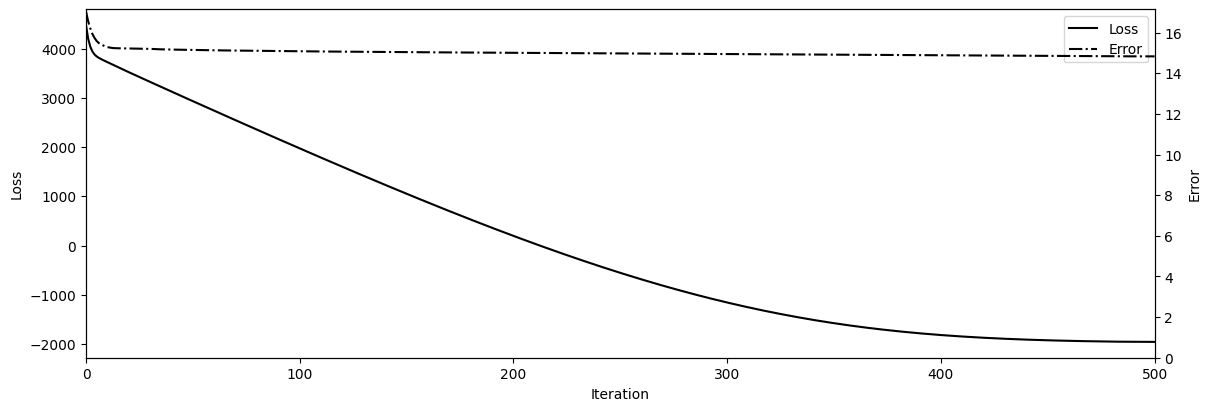

In [5]:
model.plot_losses();

The loss and error decline rapidly and consistently, confirming that training was succesfull. The following kernel and model parameters have been obtained.

In [6]:
model.print_parameters()